In [5]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import os
print(os.getcwd())

/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks


In [7]:
# Load twitch dataset

DATA_PATH = "../data/raw/twitch/100k_a.csv"

columns = [
    "user_id",
    "stream_id",
    "streamer",
    "start_time",
    "stop_time"
]

df = pd.read_csv(
    DATA_PATH,
    names=columns
)

df.head()

,user_id,stream_id,streamer,start_time,stop_time
0,1,33842865744,mithrain,154,156
1,1,33846768288,alptv,166,169
2,1,33886469056,mithrain,587,588
3,1,33887624992,wtcn,589,591
4,1,33890145056,jrokezftw,591,594


In [8]:
# Basic shape

print("Dataset shape:", df.shape)
print(f"Number of interactions: {len(df):,}")

Dataset shape: (3051733, 5)
Number of interactions: 3,051,733


In [9]:
# Data types 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3051733 entries, 0 to 3051732
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   user_id     int64
 1   stream_id   int64
 2   streamer    str  
 3   start_time  int64
 4   stop_time   int64
dtypes: int64(4), str(1)
memory usage: 142.2 MB


In [10]:
# Missing values

df.isna().sum()

user_id       0
stream_id     0
streamer      0
start_time    0
stop_time     0
dtype: int64

In [11]:
#Number of unique users, streamers, and streams

print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique streamers: {df['streamer'].nunique():,}")
print(f"Unique streams: {df['stream_id'].nunique():,}")



Unique users: 100,000
Unique streamers: 162,625
Unique streams: 739,991


In [12]:
# — Calculate watch duration

df["duration_intervals"] = df["stop_time"] - df["start_time"]

df["watch_minutes"] = df["duration_intervals"] * 10

df[
    [
        "user_id",
        "streamer",
        "start_time",
        "stop_time",
        "watch_minutes"
    ]
].head()

,user_id,streamer,start_time,stop_time,watch_minutes
0,1,mithrain,154,156,20
1,1,alptv,166,169,30
2,1,mithrain,587,588,10
3,1,wtcn,589,591,20
4,1,jrokezftw,591,594,30


In [13]:
#Watch-duration statistics

df["watch_minutes"].describe()

count    3.051733e+06
mean     3.142054e+01
std      4.257966e+01
min      1.000000e+01
25%      1.000000e+01
50%      1.000000e+01
75%      3.000000e+01
max      9.700000e+02
Name: watch_minutes, dtype: float64

In [14]:
#— Check suspicious durations

print("Zero or negative durations:")
print((df["watch_minutes"] <= 0).sum())

print()

print("Longest viewing session:")
display(
    df.loc[
        df["watch_minutes"].idxmax()
    ]
)

Zero or negative durations:
0

Longest viewing session:


user_id                         96234
stream_id                 34204026640
streamer              beyondthesummit
start_time                       3933
stop_time                        4030
duration_intervals                 97
watch_minutes                     970
Name: 2936758, dtype: object

In [15]:
#Interactions per user

interactions_per_user = (
    df.groupby("user_id")
      .size()
      .sort_values(ascending=False)
)

interactions_per_user.describe()

count    100000.000000
mean         30.517330
std          34.179094
min           5.000000
25%           8.000000
50%          16.000000
75%          39.000000
max         327.000000
dtype: float64

In [16]:
# Unique streamers watched per user

streamers_per_user = (
    df.groupby("user_id")["streamer"]
      .nunique()
      .sort_values(ascending=False)
)

streamers_per_user.describe()



count    100000.000000
mean         15.051580
std          14.780537
min           1.000000
25%           5.000000
50%          10.000000
75%          19.000000
max         295.000000
Name: streamer, dtype: float64

In [17]:
# Most active users

interactions_per_user.head(10)

user_id
42161    327
43043    319
17309    309
9308     305
99304    304
45796    298
67131    295
75466    292
83683    291
93772    290
dtype: int64

In [18]:
#Most watched streamers

streamer_interactions = (
    df.groupby("streamer")
      .size()
      .sort_values(ascending=False)
)

streamer_interactions.head(20)

streamer
ninja             45144
tfue              40136
shroud            27362
riotgames         17633
sodapoppin        14590
nickmercs         14047
dakotaz           13902
asmongold         13186
summit1g          13039
esl_csgo          12547
timthetatman      12388
xqcow             11977
symfuhny          11737
gotaga            11465
solaryfortnite    11413
fortnite           9684
tsm_hamlinz        9476
tfblade            9274
lirik              8911
loltyler1          8626
dtype: int64

In [19]:
#Number of unique viewers per streamer

viewers_per_streamer = (
    df.groupby("streamer")["user_id"]
      .nunique()
      .sort_values(ascending=False)
)

viewers_per_streamer.head(20)

streamer
ninja             17154
tfue              14460
shroud            11011
riotgames          7747
sodapoppin         5982
nickmercs          5953
dakotaz            5939
fortnite           5721
timthetatman       5367
symfuhny           5263
summit1g           5243
esl_csgo           5170
asmongold          4677
xqcow              4069
drdisrespect       3888
drlupo             3829
tsm_myth           3787
loltyler1          3733
couragejd          3677
solaryfortnite     3657
Name: user_id, dtype: int64

In [20]:
# Repeat-consumption analysis

user_streamer_counts = (
    df.groupby(["user_id", "streamer"])
      .size()
      .reset_index(name="interaction_count")
)

user_streamer_counts.head()

,user_id,streamer,interaction_count
0,1,alptv,1
1,1,berkriptepe,1
2,1,elraenn,2
3,1,eraymaskulen,1
4,1,esl_csgo,1


In [21]:
#How often do users revisit the same streamer?

repeat_pairs = (
    user_streamer_counts["interaction_count"] > 1
).sum()

total_pairs = len(user_streamer_counts)

repeat_percentage = (
    repeat_pairs / total_pairs
) * 100

print(f"Unique user-streamer pairs: {total_pairs:,}")
print(f"Repeated user-streamer pairs: {repeat_pairs:,}")
print(f"Repeated pairs: {repeat_percentage:.2f}%")

Unique user-streamer pairs: 1,505,158
Repeated user-streamer pairs: 547,897
Repeated pairs: 36.40%


In [22]:
# Distribution of repeat interactions
user_streamer_counts["interaction_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.505158e+06
mean     2.027517e+00
std      2.137354e+00
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      4.000000e+00
95%      6.000000e+00
99%      1.100000e+01
max      9.200000e+01
Name: interaction_count, dtype: float64

In [23]:
# User history example

example_user = df["user_id"].iloc[0]

user_history = (
    df[df["user_id"] == example_user]
    .sort_values("start_time")
)

print("Example user:", example_user)

display(
    user_history[
        [
            "streamer",
            "stream_id",
            "start_time",
            "stop_time",
            "watch_minutes"
        ]
    ].head(20)
)

Example user: 1


,streamer,stream_id,start_time,stop_time,watch_minutes
0,mithrain,33842865744,154,156,20
1,alptv,33846768288,166,169,30
2,mithrain,33886469056,587,588,10
3,wtcn,33887624992,589,591,20
4,jrokezftw,33890145056,591,594,30
5,berkriptepe,33903958784,734,737,30
6,kendinemuzisyen,33929318864,1021,1036,150
7,wtcn,33942837056,1165,1167,20
8,kendinemuzisyen,33955351648,1295,1297,20
10,unlostv,34062621584,2454,2456,20


In [24]:
#User's favorite streamers

favorite_streamers = (
    user_history.groupby("streamer")
    .agg(
        interactions=("streamer", "size"),
        total_watch_minutes=("watch_minutes", "sum")
    )
    .sort_values(
        "total_watch_minutes",
        ascending=False
    )
)

favorite_streamers.head(10)

,interactions,total_watch_minutes
streamer,,
kendinemuzisyen,5,320
wtcn,5,110
mithrain,8,100
jahrein,3,90
unlostv,2,60
grimnax,2,60
towshun,3,60
jtgtv,2,50
ogrencievi,3,50


In [25]:
# Sparsity recommendation matrix

n_users = df["user_id"].nunique()
n_streamers = df["streamer"].nunique()

possible_interactions = n_users * n_streamers

observed_pairs = (
    df[["user_id", "streamer"]]
    .drop_duplicates()
    .shape[0]
)

density = observed_pairs / possible_interactions
sparsity = 1 - density

print(f"Users: {n_users:,}")
print(f"Streamers: {n_streamers:,}")
print(f"Possible user-streamer pairs: {possible_interactions:,}")
print(f"Observed user-streamer pairs: {observed_pairs:,}")
print(f"Matrix density: {density:.6%}")
print(f"Matrix sparsity: {sparsity:.6%}")

Users: 100,000
Streamers: 162,625
Possible user-streamer pairs: 16,262,500,000
Observed user-streamer pairs: 1,505,158
Matrix density: 0.009255%
Matrix sparsity: 99.990745%


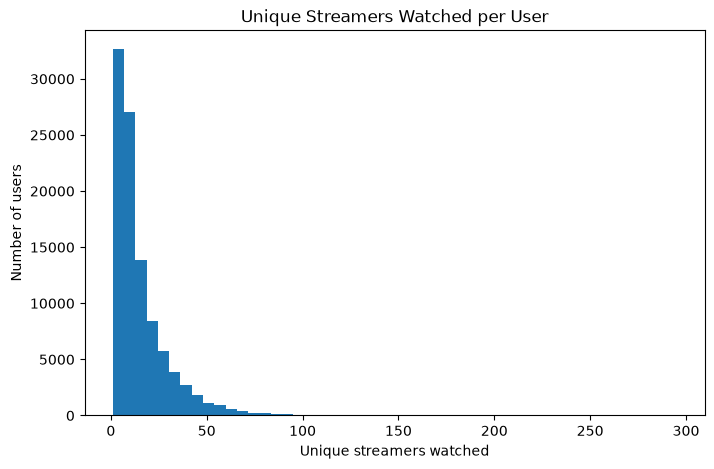

In [26]:
#Plot number of unique streamers per user

plt.figure(figsize=(8, 5))

plt.hist(
    streamers_per_user,
    bins=50
)

plt.xlabel("Unique streamers watched")
plt.ylabel("Number of users")
plt.title("Unique Streamers Watched per User")

plt.show()

In [27]:
#Popularity concentration

streamer_share = (
    streamer_interactions
    / streamer_interactions.sum()
)

cumulative_share = streamer_share.cumsum()

top_1_percent = max(
    int(len(streamer_share) * 0.01),
    1
)

share_top_1_percent = (
    streamer_share.iloc[:top_1_percent].sum()
)

print(
    f"Top 1% of streamers account for "
    f"{share_top_1_percent:.2%} of interactions."
)

Top 1% of streamers account for 59.98% of interactions.


In [28]:
# Initial datset summary
summary = pd.DataFrame(
    {
        "metric": [
            "Interactions",
            "Users",
            "Streamers",
            "Streams",
            "Unique user-streamer pairs",
            "Matrix density",
            "Median interactions per user",
            "Median streamers per user",
            "Median watch minutes"
        ],
        "value": [
            f"{len(df):,}",
            f"{n_users:,}",
            f"{n_streamers:,}",
            f"{df['stream_id'].nunique():,}",
            f"{observed_pairs:,}",
            f"{density:.6%}",
            f"{interactions_per_user.median():.0f}",
            f"{streamers_per_user.median():.0f}",
            f"{df['watch_minutes'].median():.0f}"
        ]
    }
)

summary

,metric,value
0,Interactions,"3,051,733"
1,Users,"100,000"
2,Streamers,"162,625"
3,Streams,"739,991"
4,Unique user-streamer pairs,"1,505,158"
5,Matrix density,0.009255%
6,Median interactions per user,16
7,Median streamers per user,10
8,Median watch minutes,10


In [29]:
df["watch_minutes"].median()

10.0

In [30]:
# Save notebook results: tables + figures

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results/01_twitch_data_exploration")
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Save all pandas DataFrames and Series
# --------------------------------------------------

saved_tables = []

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    try:
        if isinstance(obj, pd.DataFrame):
            output_path = TABLES_DIR / f"{name}.csv"
            obj.to_csv(output_path, index=True)
            saved_tables.append(output_path.name)

        elif isinstance(obj, pd.Series):
            output_path = TABLES_DIR / f"{name}.csv"
            obj.to_csv(output_path, header=True)
            saved_tables.append(output_path.name)

    except Exception as e:
        print(f"Could not save {name}: {e}")


# --------------------------------------------------
# Save all currently open matplotlib figures
# --------------------------------------------------

saved_figures = []

for fig_num in plt.get_fignums():

    fig = plt.figure(fig_num)

    output_path = (
        FIGURES_DIR /
        f"figure_{fig_num:02d}.png"
    )

    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    saved_figures.append(output_path.name)


# --------------------------------------------------
# Save important scalar results
# --------------------------------------------------

scalar_results = {}

important_variables = [
    "n_users",
    "n_streamers",
    "observed_pairs",
    "possible_interactions",
    "density",
    "sparsity",
    "repeat_pairs",
    "total_pairs",
    "repeat_percentage",
    "share_top_1_percent",
]

for variable in important_variables:

    if variable in globals():

        value = globals()[variable]

        if isinstance(value, (np.integer,)):
            value = int(value)

        elif isinstance(value, (np.floating,)):
            value = float(value)

        scalar_results[variable] = value


scalar_df = pd.DataFrame(
    scalar_results.items(),
    columns=["metric", "value"]
)

scalar_df.to_csv(
    RESULTS_DIR / "key_metrics.csv",
    index=False
)


# --------------------------------------------------
# Confirmation
# --------------------------------------------------

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Tables saved: {len(saved_tables)}")
print(f"Figures saved: {len(saved_figures)}")
print("Key metrics saved: key_metrics.csv")

Results directory: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/01_twitch_data_exploration
Tables saved: 11
Figures saved: 0
Key metrics saved: key_metrics.csv
